In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pytensor
pytensor.config.cxx = ""             # отключаем C++ компиляцию
pytensor.config.mode = "FAST_COMPILE"

In [3]:
df = pd.read_csv('train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


# EDA

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

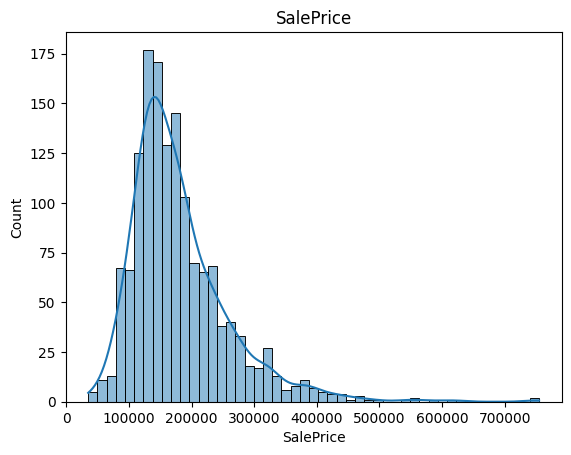

In [6]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice")
plt.show()

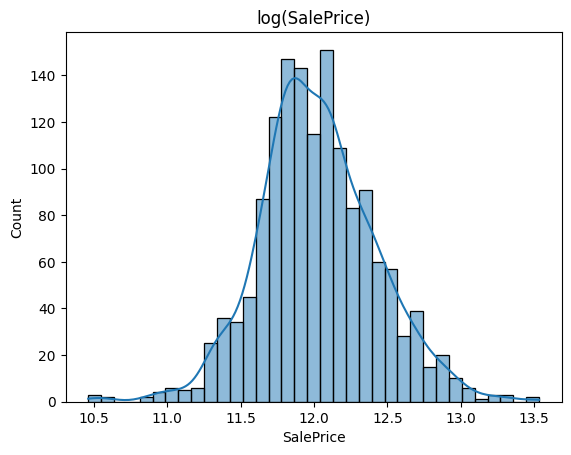

In [7]:
import numpy as np
sns.histplot(np.log(df["SalePrice"]), kde=True)
plt.title("log(SalePrice)")
plt.show()

In [8]:
df.isna().mean().sort_values(ascending=False).head(20)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
GarageQual      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
Id              0.000000
dtype: float64

In [9]:
drop_cols = df.columns[df.isna().mean() > 0.15]
df.drop(columns=drop_cols, inplace=True)

In [10]:
df["log_SalePrice"] = np.log(df["SalePrice"])

In [11]:
target = "SalePrice"
target_log = "log_SalePrice"
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_67437/3651901461.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [12]:

corr = df[num_cols].corr()[target_log]
corr_num = corr.abs().sort_values(ascending=False).head(10)
corr_num

log_SalePrice    1.000000
SalePrice        0.948374
OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
Name: log_SalePrice, dtype: float64

# Первая модель

In [13]:
import bambi as bmb

In [14]:
num_features = ["GrLivArea", "OverallQual"]
group_feature = "Neighborhood"
target_log = "log_SalePrice"

In [15]:
cols_needed = [target_log] + num_features + [group_feature]
df_model = df[cols_needed].dropna()

In [19]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

In [20]:
formula = "log_SalePrice ~ scale(GrLivArea) + scale(OverallQual) + (1 | Neighborhood)"
bm = bmb.Model(formula, data=train_df)
bm

       Formula: log_SalePrice ~ scale(GrLivArea) + scale(OverallQual) + (1 | Neighborhood)
        Family: gaussian
          Link: mu = identity
  Observations: 1168
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 12.0307, sigma: 0.9761)
            scale(GrLivArea) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(OverallQual) ~ Normal(mu: 0.0, sigma: 0.9761)
        
        Group-level effects
            1|Neighborhood ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.9761))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.3904)

In [21]:
results = bm.fit(
    draws=5000,          # число выборок из постериора
    tune=2000,           # шаги прогрева
    chains=4,            # количество цепей
    random_seed=42
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, scale(GrLivArea), scale(OverallQual), 1|Neighborhood_sigma, 1|Neighborhood_offset]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 93 seconds.


In [23]:
from sklearn.metrics import root_mean_squared_error

# Предиктивные выборки в лог-шкале
ppc_valid = bm.predict(
    idata=results,
    data=valid_df,
    kind="pps",        # posterior predictive samples
    inplace=False
)

y_valid_samples = ppc_valid.posterior_predictive["log_SalePrice"].values

# Берем медиану по chain+draw для каждого наблюдения
y_valid_log_pred = np.median(y_valid_samples, axis=(0, 1))

# Переводим в исходную шкалу
y_valid_pred = np.exp(y_valid_log_pred)
y_valid_true = np.exp(valid_df["log_SalePrice"].values)

rmse = root_mean_squared_error(y_valid_true, y_valid_pred)
print("Validation RMSE:", rmse)

/Users/vadim/Code/OTUS/ML-Advanced/.venv/lib/python3.12/site-packages/bambi/models.py:925: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


Validation RMSE: 32867.4651242151


# Вторая модель
Добавим еще фичей

In [26]:
corr_num.index[2:]

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'YearBuilt'],
      dtype='str')

In [29]:
num_features = corr_num.index[2:].to_list()

In [49]:
cols_needed = [target_log] + num_features + [group_feature]
df_model = df[cols_needed].dropna()
df_model = df_model.rename(columns={"1stFlrSF": "FirstFlrSF"})
cols_needed.append("FirstFlrSF")
cols_needed.remove("1stFlrSF")
num_features.append("FirstFlrSF")
num_features.remove("1stFlrSF")


In [50]:
formula  = target_log + " ~ " + (" + ").join([f"scale({f})" for f in num_features]) + "+ (1 | Neighborhood)"
formula

'log_SalePrice ~ scale(OverallQual) + scale(GrLivArea) + scale(GarageCars) + scale(GarageArea) + scale(TotalBsmtSF) + scale(FullBath) + scale(YearBuilt) + scale(FirstFlrSF)+ (1 | Neighborhood)'

In [51]:
train_df, valid_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42
)

In [52]:
bm2 = bmb.Model(formula, data=train_df)
bm2

       Formula: log_SalePrice ~ scale(OverallQual) + scale(GrLivArea) + scale(GarageCars) + scale(GarageArea) + scale(TotalBsmtSF) + scale(FullBath) + scale(YearBuilt) + scale(FirstFlrSF)+ (1 | Neighborhood)
        Family: gaussian
          Link: mu = identity
  Observations: 1168
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 12.0307, sigma: 0.9761)
            scale(OverallQual) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(GrLivArea) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(GarageCars) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(GarageArea) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(TotalBsmtSF) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(FullBath) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(YearBuilt) ~ Normal(mu: 0.0, sigma: 0.9761)
            scale(FirstFlrSF) ~ Normal(mu: 0.0, sigma: 0.9761)
        
        Group-level effects
            1|Neighborhood ~ Normal(mu: 0.0, sigma: Half

In [54]:
results2 = bm2.fit(
    draws=5000,          # число выборок из постериора
    tune=2000,           # шаги прогрева
    chains=4,            # количество цепей
    random_seed=42
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, scale(OverallQual), scale(GrLivArea), scale(GarageCars), scale(GarageArea), scale(TotalBsmtSF), scale(FullBath), scale(YearBuilt), scale(FirstFlrSF), 1|Neighborhood_sigma, 1|Neighborhood_offset]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 110 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


In [55]:
ppc_valid = bm2.predict(
    idata=results2,
    data=valid_df,
    kind="pps",        # posterior predictive samples
    inplace=False
)

y_valid_samples = ppc_valid.posterior_predictive["log_SalePrice"].values

# Берем медиану по chain+draw для каждого наблюдения
y_valid_log_pred = np.median(y_valid_samples, axis=(0, 1))

# Переводим в исходную шкалу
y_valid_pred = np.exp(y_valid_log_pred)
y_valid_true = np.exp(valid_df["log_SalePrice"].values)

rmse = root_mean_squared_error(y_valid_true, y_valid_pred)
print("Validation RMSE:", rmse)

/Users/vadim/Code/OTUS/ML-Advanced/.venv/lib/python3.12/site-packages/bambi/models.py:925: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


Validation RMSE: 29973.418771043584
